# Sprint 4 – Feature Engineering

## Objective

The objective of this sprint is to improve the dataset by creating new meaningful features from existing variables.

Feature Engineering allows machine learning models to learn better patterns without changing the algorithm itself.

Good features often improve prediction accuracy more than simply choosing a more complex model.

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option("display.max_columns",None)

In [10]:
df = pd.read_csv("../data/ford.csv")

df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


In [4]:
df_feature = df.copy()

In [7]:
from datetime import datetime

current_year = datetime.now().year

# print(current_year)

df_feature["car_age"] = current_year - df_feature["year"]

df_feature[["year","car_age"]].head()

,year,car_age
0,2017,9
1,2018,8
2,2017,9
3,2019,7
4,2019,7


In [8]:
df_feature['mileage_per_year']  = ( df_feature["mileage"]  /  (df_feature["car_age"] + 1) )

In [9]:
df_feature['mileage_per_year'] 

0        1594.400000
1        1009.222222
2        1245.600000
3        1307.500000
4         185.250000
            ...     
17961    1670.000000
17962    3130.769231
17963     584.166667
17964     556.333333
17965     417.250000
Name: mileage_per_year, Length: 17966, dtype: float64

In [15]:
def engine_category(engine):

    if engine <= 1.2:
        return "small"
    
    elif engine <= 2.0:
        return 'medium'
    
    else:
        return "large"

In [17]:
df_feature["engine_category"] = (df_feature["engineSize"].apply(engine_category))
df_feature

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,engine_category
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,9,1594.400000,small
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0,8,1009.222222,small
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0,9,1245.600000,small
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5,7,1307.500000,medium
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,7,185.250000,small
...,...,...,...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4,9,1670.000000,medium
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0,12,3130.769231,small
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6,11,584.166667,medium
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2,8,556.333333,small


In [18]:
def fuel_efficiency(mpg):

    if mpg<40:
        return "low"
    
    elif mpg<60:
        return "medium"
    else:
        return "high"

In [21]:
df_feature["fuel_efficiency"] = (df_feature["mpg"].apply(fuel_efficiency))


In [22]:
def tax_category(tax):
    if tax<100:
        return "low"
    elif tax<200:
        return "medium"
    else:
        return "high"

In [23]:
df_feature["tax_category"] = (df_feature["tax"].apply(tax_category))

In [24]:
df_feature["price_segment"] = pd.qcut(
    df_feature["price"],
    q=4,
    labels=["Budget","Economy","Premium","Luxury"]
)

In [27]:
df_feature.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,engine_category,fuel_efficiency,tax_category,price_segment
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,9,1594.400000,small,medium,medium,Premium
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0,8,1009.222222,small,medium,medium,Premium
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0,9,1245.600000,small,medium,medium,Premium
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5,7,1307.500000,medium,medium,medium,Luxury
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,7,185.250000,small,medium,medium,Luxury
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6,11,2952.666667,medium,medium,medium,Economy
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0,7,253.625000,small,medium,medium,Luxury
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2,9,1305.400000,small,medium,medium,Economy
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0,7,861.750000,medium,medium,medium,Luxury
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0,8,5349.000000,small,high,medium,Economy


In [28]:
df_feature.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'car_age', 'mileage_per_year', 'engine_category',
       'fuel_efficiency', 'tax_category', 'price_segment'],
      dtype='str')

In [29]:
df_feature.isnull().sum()

model               0
year                0
price               0
transmission        0
mileage             0
fuelType            0
tax                 0
mpg                 0
engineSize          0
car_age             0
mileage_per_year    0
engine_category     0
fuel_efficiency     0
tax_category        0
price_segment       0
dtype: int64

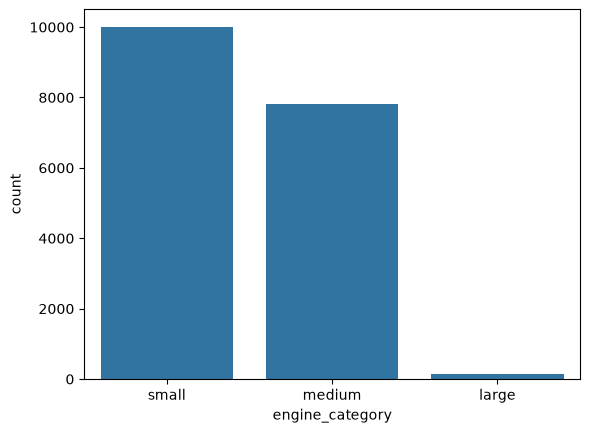

In [31]:
sns.countplot(data= df_feature , x="engine_category")

plt.show()

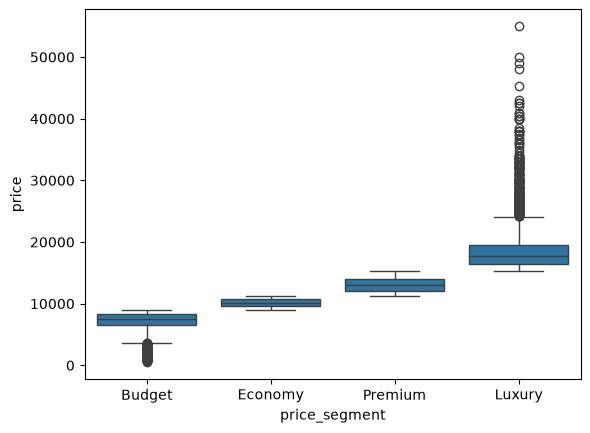

In [34]:
sns.boxplot(data= df_feature , x="price_segment",y="price")
plt.show()

In [35]:
df_feature.to_csv(
    "../data/interim/featured_ford.csv",
    index=False
)

# Sprint 4 Summary

Today I learned:

- What Feature Engineering is.
- Why new features improve machine learning models.
- How to create new numerical and categorical features.
- How to validate engineered features.
- How to save intermediate datasets.